# Extensions — Google Colab

**Project:** Vision-Language Models in Radiology

This notebook covers all three research extensions:

| Extension | Description | Prerequisite |
|-----------|-------------|-------------|
| **Ext 1** | Uncertainty-Aware Classification (MC Dropout + Conformal Prediction) | CheXzero best.pt + NIH-14 |
| **Ext 2** | Factuality-Constrained Generation (Proxy RadGraph loss fine-tuning) | R2Gen best.pt + IU X-Ray |
| **Ext 3** | Cross-Dataset Robustness (zero-shot → few-shot on NIH-14) | CheXzero best.pt + NIH-14 |

> **Runtime:** T4 GPU.  
> **Prerequisites:** Run `chexzero_colab.ipynb` and/or `r2gen_colab.ipynb` first to produce the required checkpoints.

---
## 0. Setup

In [ ]:
import os, sys, logging

REPO_URL = "https://github.com/SinaDns/radiology-vision-language-models.git"
REPO_DIR = "/content/radiology-vision-language-models"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

!pip install -q -r requirements.txt

In [2]:
import sys, os, logging
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s',
    datefmt='%H:%M:%S',
)

import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


In [4]:
from pathlib import Path
REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() \
            else Path(os.getcwd()).parent if Path(os.getcwd()).name == "experiments" \
            else Path(os.getcwd())

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root :", REPO_ROOT)
print("CWD       :", os.getcwd())
print("src exists:", (REPO_ROOT / "src").is_dir())

Repo root : /home/dev/KD-project/radiology-vision-language-models
CWD       : /home/dev/KD-project/radiology-vision-language-models
src exists: True


In [ ]:
# Download R2Gen checkpoint from Google Drive
import os
from pathlib import Path

# ── CONFIG ──────────────────────────────────────────────────────────────────
GDRIVE_FILE_ID = "1GCZO6g19WNOMflEuy_R3Ml2xn_WbXXvg"
R2GEN_CKPT     = "experiments/results/checkpoints/r2gen/best.pt"
# ────────────────────────────────────────────────────────────────────────────

Path(R2GEN_CKPT).parent.mkdir(parents=True, exist_ok=True)

try:
    import gdown
except ImportError:
    os.system("pip install -q gdown")
    import gdown

url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
gdown.download(url, R2GEN_CKPT, quiet=False)

assert os.path.exists(R2GEN_CKPT), "Download failed — check the file ID and sharing permissions."
print(f"✅  R2Gen checkpoint saved to: {R2GEN_CKPT}  ({os.path.getsize(R2GEN_CKPT)/1e6:.1f} MB)")

In [5]:
# ── Mount Google Drive to load checkpoints ────────────────────────────────────
# Uncomment if checkpoints are saved to Drive:
# from google.colab import drive
# drive.mount("/content/drive")

# Set checkpoint paths
CHEXZERO_CKPT = "experiments/results/checkpoints/chexzero/best.pt"
R2GEN_CKPT    = "experiments/results/checkpoints/r2gen/best.pt"
VOCAB_PATH    = "experiments/results/r2gen_vocab.json"

# Override if loading from Drive:
# CHEXZERO_CKPT = "/content/drive/MyDrive/chexzero_best.pt"
# R2GEN_CKPT    = "/content/drive/MyDrive/r2gen_best.pt"

import os
for p in [CHEXZERO_CKPT, R2GEN_CKPT]:
    if os.path.exists(p):
        print(f"✓ Found: {p}")
    else:
        print(f"✗ Missing: {p}  (run the prerequisite notebook first)")

✓ Found: experiments/results/checkpoints/chexzero/best.pt
✓ Found: experiments/results/checkpoints/r2gen/best.pt


---
## Extension 1: Uncertainty-Aware Classification

**Goal:** Quantify epistemic uncertainty with MC Dropout; calibrate predictions with conformal prediction to guarantee 90% coverage.

**Targets:** ECE reduction 20-30%, coverage ≥ 90% at α=0.10.

**Prerequisites:** CheXzero best.pt, NIH-14 dataset (see Section 5 of `chexzero_colab.ipynb`).

In [7]:
from src.models.chexzero import CheXzero
from src.models.uncertainty import MCDropoutCheXzero, ConformalPredictor

base_model = CheXzero(embed_dim=512)
ckpt = torch.load(CHEXZERO_CKPT, map_location=device)
base_model.load_state_dict(ckpt["model_state_dict"])

mc_model = MCDropoutCheXzero(
    chexzero=base_model,
    dropout_rate=0.1,
    n_samples=10,   # 10 MC passes is sufficient; 20 may OOM on T4
)
mc_model.to(device)
print(f"MC Dropout model ready — epoch {ckpt.get('epoch', '?')}")

/home/dev/KD-project/radiology-vision-language-models/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
12:51:32 [INFO] src.models.chexzero — ImageEncoder — embed_dim=512 pretrained=True params=24.56M
12:51:32 [INFO] src.models.chexzero — TextEncoder — loading emilyalsentzer/Bio_ClinicalBERT …
12:51:33 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
12:51:33 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/config.json "HTTP/1.1 200 OK"
12:51:33 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
12:51:33 [

MC Dropout model ready — epoch 1


In [8]:
# Pre-compute text embeddings
from transformers import AutoTokenizer
from src.evaluation.zero_shot import PATHOLOGY_PROMPTS, _encode_prompts
from src.data_loaders.nih_chestxray14 import NIH14_LABELS

tokenizer_bert = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

text_embs = []
for label in NIH14_LABELS:
    pos_list = PATHOLOGY_PROMPTS.get(label, {}).get(
        "positive", [f"findings consistent with {label.lower()}"]
    )
    embs = _encode_prompts(base_model, pos_list, tokenizer_bert, device)
    text_embs.append(embs.mean(0, keepdim=True))
text_embs_t = torch.cat(text_embs, 0).to(device)
print(f"Text embeddings: {text_embs_t.shape}")

12:51:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
12:51:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/config.json "HTTP/1.1 200 OK"
12:51:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
12:51:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
12:51:43 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
12:51:43 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/tree/main?recursive=true&ex

Text embeddings: torch.Size([14, 512])


In [9]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent

# NIH-14 test set — update path as needed
NIH14_DIR  = BASE_DIR / "radiology-vision-language-models" / "data" / "nih_chestxray14"
TEST_CSV   = NIH14_DIR / "test_list.txt"
CALIB_CSV  = NIH14_DIR / "train_val_list.txt"

import os
if not os.path.exists(NIH14_DIR / "images"):
    print("NIH-14 not found. Follow Section 5 of chexzero_colab.ipynb to download.")
else:
    from src.data_loaders.nih_chestxray14 import NIHChestXray14Dataset
    from src.data_loaders.transforms import get_val_transforms
    from torch.utils.data import DataLoader

    test_ds  = NIHChestXray14Dataset(NIH14_DIR, split="test",  split_csv=TEST_CSV,  transform=get_val_transforms(320))
    calib_ds = NIHChestXray14Dataset(NIH14_DIR, split="train", split_csv=CALIB_CSV, transform=get_val_transforms(320))
    # batch_size=32 for T4 safety; increase to 64 for A100
    test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    calib_loader = DataLoader(calib_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    print(f"Test: {len(test_ds)}  Calibration: {len(calib_ds)}")

12:51:49 [INFO] src.data_loaders.nih_chestxray14 — NIHChestXray14Dataset init — data_dir=/home/dev/KD-project/radiology-vision-language-models/data/nih_chestxray14 split=test split_csv=/home/dev/KD-project/radiology-vision-language-models/data/nih_chestxray14/test_list.txt
12:51:49 [INFO] src.data_loaders.nih_chestxray14 — Loaded metadata CSV — total rows: 112120
12:51:49 [INFO] src.data_loaders.nih_chestxray14 — Applied split filter 'test': 112120 → 25596 rows
12:51:51 [WARNING] src.data_loaders.nih_chestxray14 — 24629 image files listed in CSV but not found on disk (check extraction completeness)
12:51:51 [INFO] src.data_loaders.nih_chestxray14 — Built 967 valid samples (24629 missing images skipped)
12:51:51 [INFO] src.data_loaders.nih_chestxray14 — Dataset ready — 967 samples, labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
12:51:51 [

Test: 967  Calibration: 4032


In [10]:
import numpy as np

# MC Dropout scoring on test set
all_mean, all_unc, all_labels = [], [], []

for batch_idx, batch in enumerate(test_loader):
    images = batch["image"].to(device)
    out = mc_model.predict_with_uncertainty(images, text_embs_t, n_samples=10)
    all_mean.append(out["mean_scores"].cpu().numpy())
    all_unc.append(out["uncertainty"].cpu().numpy())
    all_labels.append(batch["labels"].numpy())
    if (batch_idx+1) % 50 == 0:
        print(f"Scored {batch_idx+1}/{len(test_loader)} batches")

mean_scores = np.concatenate(all_mean)
uncertainty = np.concatenate(all_unc)
labels_np   = np.concatenate(all_labels)
print(f"Scored {len(labels_np)} test images")
print(f"Mean uncertainty: {uncertainty.mean():.4f}")

Scored 967 test images
Mean uncertainty: 0.0002


In [11]:
from src.evaluation.metrics import compute_auroc, classification_report

scores_dict = {l: mean_scores[:, i] for i, l in enumerate(NIH14_LABELS)}
labels_dict = {l: labels_np[:, i]   for i, l in enumerate(NIH14_LABELS)}
auroc = compute_auroc(scores_dict, labels_dict)

print("=== MC Dropout Zero-Shot AUROC ===")
print(classification_report(mean_scores, labels_np, label_names=NIH14_LABELS))
print(f"\nMean AUROC: {auroc['mean_auroc']:.4f}")

=== MC Dropout Zero-Shot AUROC ===
Label                        AUROC    AUPRC   Prevalence
---------------------------------------------------------
Atelectasis                 0.5378   0.1596       0.1293
Cardiomegaly                0.5856   0.1471       0.0972
Consolidation               0.5570   0.0731       0.0641
Edema                       0.6822   0.1241       0.0362
Effusion                    0.6155   0.2439       0.1551
Emphysema                   0.6262   0.0621       0.0434
Fibrosis                    0.6412   0.1000       0.0310
Hernia                      0.6200   0.0273       0.0155
Infiltration                0.5628   0.2857       0.2234
Mass                        0.6397   0.0834       0.0434
Nodule                      0.5662   0.0412       0.0362
Pleural_Thickening          0.5118   0.0698       0.0600
Pneumonia                   0.4851   0.0203       0.0186
Pneumothorax                0.5213   0.1247       0.1200
----------------------------------------------------

In [12]:
# Conformal prediction calibration
calib_scores_list, calib_labels_list = [], []
for batch in calib_loader:
    imgs = batch["image"].to(device)
    with torch.no_grad():
        emb = base_model.encode_image(imgs).cpu()
        sc  = (emb @ text_embs_t.cpu().T).numpy()
    calib_scores_list.append(sc)
    calib_labels_list.append(batch["labels"].numpy())

calib_scores = np.concatenate(calib_scores_list)
calib_labels = np.concatenate(calib_labels_list)

predictor = ConformalPredictor(alpha=0.1)
predictor.calibrate(calib_scores, calib_labels)

coverage  = predictor.compute_coverage(mean_scores, labels_np)
ece_stats = predictor.compute_ece_reduction(
    calib_scores, mean_scores, labels_np,
    labels_before=calib_labels,          # calib set has different N than test set
)

print(f"\nConformal Coverage: {coverage['coverage']:.4f}  (target ≥ 0.90)")
print(f"Avg prediction set size: {coverage['avg_set_size']:.2f} / 14")
print(f"ECE before: {ece_stats['ece_before']:.4f}")
print(f"ECE after:  {ece_stats['ece_after']:.4f}")
print(f"ECE reduction: {ece_stats['ece_reduction']:.1%}  (target 20-30%)")

12:52:57 [INFO] src.models.uncertainty — ConformalPredictor — alpha=0.10
12:52:57 [INFO] src.models.uncertainty — Conformal calibration done — N=4032 C=14 alpha=0.10 mean_threshold=0.7976
12:52:57 [INFO] src.models.uncertainty — Coverage=0.8925 (target=0.9000) avg_set_size=11.39
12:52:57 [INFO] src.models.uncertainty — ECE before=0.5302 after=0.4949 reduction=6.7%



Conformal Coverage: 0.8925  (target ≥ 0.90)
Avg prediction set size: 11.39 / 14
ECE before: 0.5302
ECE after:  0.4949
ECE reduction: 6.7%  (target 20-30%)


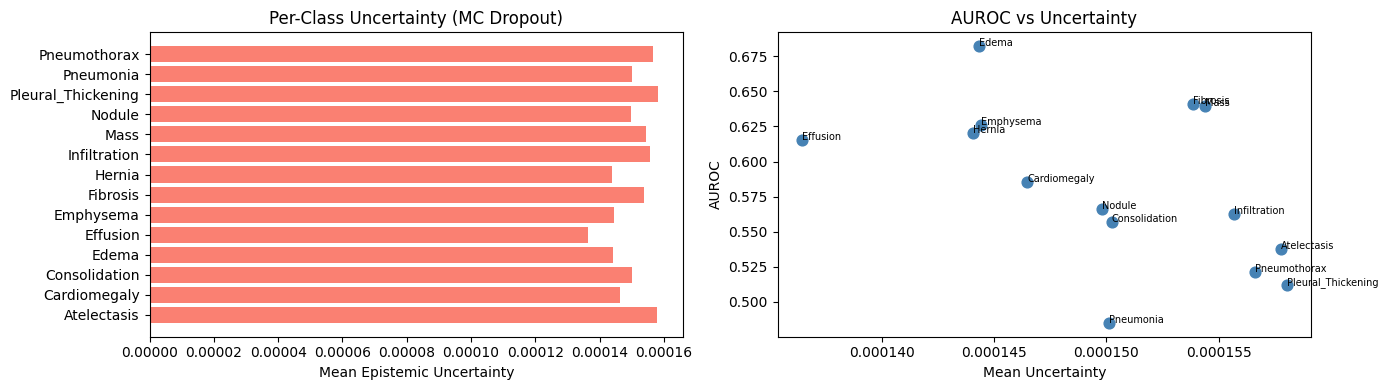

Plot saved to experiments/results/ext1_uncertainty.png


In [13]:
# Uncertainty visualisation
import matplotlib.pyplot as plt
import os

os.makedirs("experiments/results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-class uncertainty
mean_unc_per_class = uncertainty.mean(axis=0)
axes[0].barh(NIH14_LABELS, mean_unc_per_class, color='salmon')
axes[0].set_xlabel('Mean Epistemic Uncertainty')
axes[0].set_title('Per-Class Uncertainty (MC Dropout)')

# Right: AUROC vs uncertainty scatter
auroc_vals = [auroc.get(l, 0) for l in NIH14_LABELS]
axes[1].scatter(mean_unc_per_class, auroc_vals, color='steelblue', s=60)
for i, l in enumerate(NIH14_LABELS):
    axes[1].annotate(l, (mean_unc_per_class[i], auroc_vals[i]), fontsize=7)
axes[1].set_xlabel('Mean Uncertainty')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC vs Uncertainty')

plt.tight_layout()
plt.savefig('experiments/results/ext1_uncertainty.png', dpi=150)
plt.show()
print("Plot saved to experiments/results/ext1_uncertainty.png")

---
## Extension 2: Factuality-Constrained Generation

**Goal:** Fine-tune R2Gen with a proxy clinical factuality penalty to reduce hallucinations.

**Target:** Proxy RadGraph F1 improvement after factuality fine-tuning.

**Prerequisite:** R2Gen best.pt, IU X-Ray dataset.

In [6]:
import os
from src.data_loaders.iu_xray_seq2seq import build_tokenizer

tok = build_tokenizer(
    data_dir="data/iu_xray/",
    save_path=VOCAB_PATH,
    min_freq=3,
)
print(f"Vocabulary: {tok.vocab_size} tokens")

13:03:08 [INFO] src.data_loaders.iu_xray_seq2seq — Loading cached vocabulary from experiments/results/r2gen_vocab.json
13:03:08 [INFO] src.data_loaders.report_tokenizer — Loading vocabulary from experiments/results/r2gen_vocab.json
13:03:08 [INFO] src.data_loaders.report_tokenizer — ReportTokenizer — vocab_size=1423 pad=0 unk=1 bos=2 eos=3


Vocabulary: 1423 tokens


In [7]:
from src.utils.config import load_config

fact_config = load_config("experiments/configs/factuality.yaml")
fact_config["model"]["r2gen_checkpoint"] = R2GEN_CKPT
fact_config["paths"]["iu_xray_dir"]    = "data/iu_xray/"
fact_config["paths"]["checkpoint_dir"] = "experiments/results/checkpoints/factuality/"
fact_config["paths"]["log_dir"]        = "experiments/results/logs/"
fact_config["tokenizer"]["vocab_save_path"] = VOCAB_PATH
fact_config["training"]["batch_size"]   = 8
fact_config["training"]["epochs"]       = 5   # short fine-tune
fact_config["data"]["num_workers"]      = 2
print("Factuality config ready.")

Factuality config ready.


In [8]:
import torch, os
import torch.amp
from torch.utils.data import DataLoader

from src.data_loaders.iu_xray_seq2seq import IUXraySeq2SeqDataset
from src.data_loaders.transforms import get_train_transforms, get_val_transforms
from src.models.r2gen import R2GenModel
from src.training.factuality_loss import ProxyFactualityLoss, compute_radgraph_f1
from src.evaluation.generation_metrics import compute_all_metrics, generation_report
from src.utils.logging_utils import setup_logger

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_use_amp = torch.cuda.is_available()
logger_fact = setup_logger(fact_config["paths"]["log_dir"], "factuality")

train_ds_f = IUXraySeq2SeqDataset(
    data_dir="data/iu_xray/", tokenizer=tok, split="train",
    val_fraction=0.1, transform=get_train_transforms(224), max_length=100,
)
val_ds_f = IUXraySeq2SeqDataset(
    data_dir="data/iu_xray/", tokenizer=tok, split="val",
    val_fraction=0.1, transform=get_val_transforms(224), max_length=100,
)

train_loader_f = DataLoader(train_ds_f, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader_f   = DataLoader(val_ds_f,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

mcfg = fact_config["model"]
fact_model = R2GenModel(
    vocab_size=tok.vocab_size,
    d_model=mcfg["d_model"], num_heads=mcfg["num_heads"],
    num_enc_layers=mcfg["num_enc_layers"], num_dec_layers=mcfg["num_dec_layers"],
    dim_ff=mcfg["dim_ff"], dropout=mcfg["dropout"],
    num_mem_slots=mcfg["num_mem_slots"], max_seq_len=mcfg["max_seq_len"],
    pretrained_image=False, pad_id=tok.pad_id,
)

if os.path.exists(R2GEN_CKPT):
    r2_ckpt = torch.load(R2GEN_CKPT, map_location=device)
    fact_model.load_state_dict(r2_ckpt["model_state_dict"])
    print(f"Loaded R2Gen weights (epoch {r2_ckpt.get('epoch','?')})")
else:
    print("WARNING: R2Gen checkpoint not found — training from scratch")

fact_model.to(device)
criterion = ProxyFactualityLoss(vocab=tok.word2idx, coverage_weight=0.3, pad_id=tok.pad_id)
optimizer = torch.optim.AdamW(fact_model.parameters(), lr=1e-5, weight_decay=1e-4)
scaler = torch.amp.GradScaler(device=device.type, enabled=_use_amp)

os.makedirs("experiments/results/checkpoints/factuality", exist_ok=True)
os.makedirs("experiments/results", exist_ok=True)
print("Factuality fine-tuning ready.")

13:03:14 [INFO] src.data_loaders.iu_xray — IUXrayDataset init — data_dir=data/iu_xray/ split=train
13:03:14 [INFO] src.data_loaders.iu_xray — Found 3955 XML report files, 7470 PNG images in index
13:03:15 [INFO] src.data_loaders.iu_xray — Build complete — pairs=7430  skipped(empty_report)=28  skipped(no_uri)=101  unresolved_uris=0
13:03:15 [INFO] src.data_loaders.iu_xray — Raw samples (before split): 7430
13:03:15 [INFO] src.data_loaders.iu_xray — Studies total=3826  val=382  train=3444
13:03:15 [INFO] src.data_loaders.iu_xray — [train split] 6684 image-report pairs from 3444 studies
13:03:15 [INFO] src.data_loaders.iu_xray_seq2seq — IUXraySeq2SeqDataset — split=train samples=6684 max_length=100
13:03:15 [INFO] src.data_loaders.iu_xray — IUXrayDataset init — data_dir=data/iu_xray/ split=val
13:03:15 [INFO] src.data_loaders.iu_xray — Found 3955 XML report files, 7470 PNG images in index
13:03:16 [INFO] src.data_loaders.iu_xray — Build complete — pairs=7430  skipped(empty_report)=28  ski

Loaded R2Gen weights (epoch 9)
Factuality fine-tuning ready.


In [9]:
# ── Fine-tuning loop ──────────────────────────────────────────────────────────
import time

best_val = float("inf")
epochs = fact_config["training"]["epochs"]

for epoch in range(epochs):
    fact_model.train()
    total, n = 0.0, 0
    t0 = time.time()

    for i, batch in enumerate(train_loader_f):
        imgs  = batch["image"].to(device)
        inp   = batch["input_ids"].to(device)
        tgt   = batch["target_ids"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=device.type, enabled=_use_amp):
            logits = fact_model(imgs, inp)
            loss, ce, fact_l = criterion(logits, tgt)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(fact_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item(); n += 1
        if (i+1) % 50 == 0:
            logger_fact.info(f"Epoch {epoch} [{i+1}/{len(train_loader_f)}] total={loss:.4f} ce={ce:.4f} fact={fact_l:.4f}")

    # Val
    fact_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader_f:
            imgs = batch["image"].to(device)
            inp  = batch["input_ids"].to(device)
            tgt  = batch["target_ids"].to(device)
            with torch.amp.autocast(device_type=device.type, enabled=_use_amp):
                logits = fact_model(imgs, inp)
                loss, _, _ = criterion(logits, tgt)
            val_loss += loss.item()
    val_loss /= len(val_loader_f)

    logger_fact.info(f"Epoch {epoch} done — train={total/n:.4f} val={val_loss:.4f} time={time.time()-t0:.1f}s")
    print(f"Epoch {epoch}/{epochs-1} — train_loss={total/n:.4f} val_loss={val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save({"epoch": epoch, "model_state_dict": fact_model.state_dict()},
                   "experiments/results/checkpoints/factuality/best.pt")
        print(f"  Saved new best checkpoint")

print(f"\nFactuality fine-tuning done — best val loss: {best_val:.4f}")

/home/dev/KD-project/radiology-vision-language-models/.venv/lib/python3.10/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
2026-02-24 13:03:27 [INFO] Epoch 0 [50/835] total=2.0044 ce=2.2609 fact=1.4059
13:03:27 [INFO] factuality — Epoch 0 [50/835] total=2.0044 ce=2.2609 fact=1.4059
2026-02-24 13:03:32 [INFO] Epoch 0 [100/835] total=1.7712 ce=2.0996 fact=1.0049
13:03:32 [INFO] factuality — Epoch 0 [100/835] total=1.7712 ce=2.0996 fact=1.0049
2026-02-24 13:03:37 [INFO] Epoch 0 [150/835] total=2.0461 ce=2.2458 fact=1.5800
13:03:37 [INFO] factuality — Epoch 0 [150/835] total=2.0461 ce=2.2458 fact=1.5800
2026-02-24 13:03:42 [INFO] Epoch 0 [200/835] total=1.9128 ce=2.2923 fact=1.0272
13:03:42 [INFO] factuality — Epoch 0 [200/835] total=1.9128 ce=2.2923 fact=1.0272
2026-02-24 13:03:47 [INFO] Epoch 0 [250/835] total=1.5593 ce=1.8884 fact=0

Epoch 0/4 — train_loss=1.9121 val_loss=1.9369
  Saved new best checkpoint


2026-02-24 13:04:55 [INFO] Epoch 1 [50/835] total=1.7007 ce=1.8792 fact=1.2842
13:04:55 [INFO] factuality — Epoch 1 [50/835] total=1.7007 ce=1.8792 fact=1.2842
2026-02-24 13:05:00 [INFO] Epoch 1 [100/835] total=1.8462 ce=2.2938 fact=0.8019
13:05:00 [INFO] factuality — Epoch 1 [100/835] total=1.8462 ce=2.2938 fact=0.8019
2026-02-24 13:05:05 [INFO] Epoch 1 [150/835] total=2.3051 ce=2.7464 fact=1.2755
13:05:05 [INFO] factuality — Epoch 1 [150/835] total=2.3051 ce=2.7464 fact=1.2755
2026-02-24 13:05:10 [INFO] Epoch 1 [200/835] total=2.1156 ce=2.4707 fact=1.2870
13:05:10 [INFO] factuality — Epoch 1 [200/835] total=2.1156 ce=2.4707 fact=1.2870
2026-02-24 13:05:15 [INFO] Epoch 1 [250/835] total=2.1480 ce=2.4309 fact=1.4877
13:05:15 [INFO] factuality — Epoch 1 [250/835] total=2.1480 ce=2.4309 fact=1.4877
2026-02-24 13:05:20 [INFO] Epoch 1 [300/835] total=1.6740 ce=1.9318 fact=1.0725
13:05:20 [INFO] factuality — Epoch 1 [300/835] total=1.6740 ce=1.9318 fact=1.0725
2026-02-24 13:05:25 [INFO] Epo

Epoch 1/4 — train_loss=1.8959 val_loss=1.9255
  Saved new best checkpoint


2026-02-24 13:06:22 [INFO] Epoch 2 [50/835] total=1.5036 ce=1.8785 fact=0.6287
13:06:22 [INFO] factuality — Epoch 2 [50/835] total=1.5036 ce=1.8785 fact=0.6287
2026-02-24 13:06:27 [INFO] Epoch 2 [100/835] total=1.3766 ce=1.6700 fact=0.6920
13:06:27 [INFO] factuality — Epoch 2 [100/835] total=1.3766 ce=1.6700 fact=0.6920
2026-02-24 13:06:32 [INFO] Epoch 2 [150/835] total=1.6693 ce=1.9384 fact=1.0414
13:06:32 [INFO] factuality — Epoch 2 [150/835] total=1.6693 ce=1.9384 fact=1.0414
2026-02-24 13:06:37 [INFO] Epoch 2 [200/835] total=1.7070 ce=1.9840 fact=1.0609
13:06:37 [INFO] factuality — Epoch 2 [200/835] total=1.7070 ce=1.9840 fact=1.0609
2026-02-24 13:06:42 [INFO] Epoch 2 [250/835] total=2.3140 ce=2.8363 fact=1.0950
13:06:42 [INFO] factuality — Epoch 2 [250/835] total=2.3140 ce=2.8363 fact=1.0950
2026-02-24 13:06:47 [INFO] Epoch 2 [300/835] total=2.2954 ce=2.7616 fact=1.2074
13:06:47 [INFO] factuality — Epoch 2 [300/835] total=2.2954 ce=2.7616 fact=1.2074
2026-02-24 13:06:52 [INFO] Epo

Epoch 2/4 — train_loss=1.8735 val_loss=1.9187
  Saved new best checkpoint


2026-02-24 13:07:50 [INFO] Epoch 3 [50/835] total=1.9251 ce=2.2361 fact=1.1994
13:07:50 [INFO] factuality — Epoch 3 [50/835] total=1.9251 ce=2.2361 fact=1.1994
2026-02-24 13:07:55 [INFO] Epoch 3 [100/835] total=2.5907 ce=2.9087 fact=1.8485
13:07:55 [INFO] factuality — Epoch 3 [100/835] total=2.5907 ce=2.9087 fact=1.8485
2026-02-24 13:08:00 [INFO] Epoch 3 [150/835] total=2.1241 ce=2.3352 fact=1.6316
13:08:00 [INFO] factuality — Epoch 3 [150/835] total=2.1241 ce=2.3352 fact=1.6316
2026-02-24 13:08:05 [INFO] Epoch 3 [200/835] total=2.4738 ce=2.9037 fact=1.4707
13:08:05 [INFO] factuality — Epoch 3 [200/835] total=2.4738 ce=2.9037 fact=1.4707
2026-02-24 13:08:10 [INFO] Epoch 3 [250/835] total=2.0753 ce=2.3950 fact=1.3293
13:08:10 [INFO] factuality — Epoch 3 [250/835] total=2.0753 ce=2.3950 fact=1.3293
2026-02-24 13:08:15 [INFO] Epoch 3 [300/835] total=1.9820 ce=2.4766 fact=0.8279
13:08:15 [INFO] factuality — Epoch 3 [300/835] total=1.9820 ce=2.4766 fact=0.8279
2026-02-24 13:08:20 [INFO] Epo

Epoch 3/4 — train_loss=1.8601 val_loss=1.9064
  Saved new best checkpoint


2026-02-24 13:09:18 [INFO] Epoch 4 [50/835] total=1.1391 ce=1.3993 fact=0.5320
13:09:18 [INFO] factuality — Epoch 4 [50/835] total=1.1391 ce=1.3993 fact=0.5320
2026-02-24 13:09:24 [INFO] Epoch 4 [100/835] total=1.8304 ce=2.0240 fact=1.3787
13:09:24 [INFO] factuality — Epoch 4 [100/835] total=1.8304 ce=2.0240 fact=1.3787
2026-02-24 13:09:29 [INFO] Epoch 4 [150/835] total=1.9779 ce=2.1857 fact=1.4930
13:09:29 [INFO] factuality — Epoch 4 [150/835] total=1.9779 ce=2.1857 fact=1.4930
2026-02-24 13:09:34 [INFO] Epoch 4 [200/835] total=2.1370 ce=2.6074 fact=1.0393
13:09:34 [INFO] factuality — Epoch 4 [200/835] total=2.1370 ce=2.6074 fact=1.0393
2026-02-24 13:09:39 [INFO] Epoch 4 [250/835] total=1.8417 ce=2.2466 fact=0.8968
13:09:39 [INFO] factuality — Epoch 4 [250/835] total=1.8417 ce=2.2466 fact=0.8968
2026-02-24 13:09:45 [INFO] Epoch 4 [300/835] total=2.1474 ce=2.4787 fact=1.3743
13:09:45 [INFO] factuality — Epoch 4 [300/835] total=2.1474 ce=2.4787 fact=1.3743
2026-02-24 13:09:50 [INFO] Epo

Epoch 4/4 — train_loss=1.8434 val_loss=1.9028
  Saved new best checkpoint

Factuality fine-tuning done — best val loss: 1.9028


In [10]:
# Compare base R2Gen vs factuality-finetuned
import torch
from src.models.r2gen import R2GenModel
from src.evaluation.generation_metrics import (
    compute_all_metrics, generation_report,
    compute_chexbert_metrics, chexbert_report,
)

def generate_reports(model, loader, tokenizer, device, max_reports=200):
    model.eval()
    hyps, refs = [], []
    for batch in loader:
        if len(hyps) >= max_reports:
            break
        imgs = batch["image"].to(device)
        seqs = model.generate(imgs, bos_id=tokenizer.bos_id,
                               eos_id=tokenizer.eos_id, beam_size=3, max_length=100)
        for s in seqs:
            hyps.append(tokenizer.decode(s))
        refs.extend(batch["report"])
    return hyps[:max_reports], refs[:max_reports]

print("Generating from factuality model…")
hyps_fact, refs_fact = generate_reports(fact_model, val_loader_f, tok, device)

# N-gram + CIDEr
metrics_fact = compute_all_metrics(hyps_fact, refs_fact)
rg_fact = compute_radgraph_f1(hyps_fact, refs_fact)

print("\n=== Factuality Fine-tuned R2Gen — N-gram + CIDEr ===")
print(generation_report(metrics_fact))
for k, v in rg_fact.items():
    print(f"{k}: {v:.4f}")

# CheXbert label F1 (downloads ~440 MB on first run; cached thereafter)
print("\nRunning CheXbert evaluation…")
cb_fact = compute_chexbert_metrics(hyps_fact, refs_fact, device=str(device), batch_size=32)
print("\n=== Factuality Fine-tuned R2Gen — CheXbert ===")
print(chexbert_report(cb_fact))

Generating from factuality model…


14:04:22 [INFO] src.evaluation.generation_metrics — Computing generation metrics on 200 samples …
14:04:38 [INFO] src.evaluation.generation_metrics — BLEU scores: {'bleu_1': 0.122, 'bleu_2': 0.0622, 'bleu_3': 0.0347, 'bleu_4': 0.0184}
14:04:38 [INFO] absl — Using default tokenizer.
14:04:39 [INFO] src.evaluation.generation_metrics — ROUGE scores: {'rouge_1': 0.3446, 'rouge_2': 0.112, 'rouge_l': 0.2676}
14:04:42 [INFO] src.evaluation.generation_metrics — METEOR score: 0.1840
14:04:42 [INFO] src.evaluation.generation_metrics — CIDEr score: 0.0582
14:04:42 [INFO] src.evaluation.generation_metrics — All generation metrics: {'bleu_1': 0.122, 'bleu_2': 0.0622, 'bleu_3': 0.0347, 'bleu_4': 0.0184, 'rouge_1': 0.3446, 'rouge_2': 0.112, 'rouge_l': 0.2676, 'meteor': 0.184, 'cider': 0.0582}
14:04:42 [WARNING] src.training.factuality_loss — RadGraph F1 unavailable (ModuleNotFoundError: No module named 'radgraph') — falling back to proxy token-overlap F1. Common cause: transformers>=4.46 removed enco


=== Factuality Fine-tuned R2Gen — N-gram + CIDEr ===
Metric             Score
------------------------
bleu_1            0.1220
bleu_2            0.0622
bleu_3            0.0347
bleu_4            0.0184
meteor            0.1840
rouge_1           0.3446
rouge_2           0.1120
rouge_l           0.2676
cider             0.0582
radgraph_f1_proxy: 0.3959

Running CheXbert evaluation…


14:04:44 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
14:04:44 [WARNING] huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
14:04:45 [INFO] httpx — HTTP Request: GET https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
14:04:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
14:04:46 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/xet-read-token/86b5e0934494bd15c9632b12f734a8a67f723594 "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 700.72it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 


=== Factuality Fine-tuned R2Gen — CheXbert ===
Condition                            F1
----------------------------------------
No Finding                       0.0000
Enlarged Cardiomediastinum       0.0000
Cardiomegaly                     1.0000
Lung Opacity                     0.0000
Lung Lesion                      0.0000
Edema                            0.0000
Consolidation                    0.0000
Pneumonia                        0.0000
Atelectasis                      1.0000
Pneumothorax                     0.0000
Pleural Effusion                 0.0000
Pleural Other                    0.0000
Fracture                         0.0000
Support Devices                  0.6928
----------------------------------------
Macro F1                         0.1923
Macro Precision                  0.1807
Macro Recall                     0.2143


---
## Extension 3: Cross-Dataset Robustness

**Goal:** Evaluate zero-shot transfer from IU X-Ray to NIH-14, then recover performance with few-shot linear probes.

**Target:** Few-shot probe recovers 50-70% of the cross-dataset performance drop.

**Prerequisite:** CheXzero best.pt, NIH-14 dataset.

In [11]:
import torch
import numpy as np
from torch.utils.data import DataLoader

from src.models.chexzero import CheXzero
from src.data_loaders.iu_xray import IUXrayDataset
from src.data_loaders.nih_chestxray14 import NIHChestXray14Dataset, NIH14_LABELS
from src.data_loaders.transforms import get_val_transforms
from src.evaluation.cross_dataset import (
    extract_embeddings, compute_domain_gap,
    few_shot_adapt, evaluate_probe, cross_dataset_report,
)
from src.evaluation.zero_shot import compute_zero_shot_scores
from src.evaluation.metrics import compute_auroc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CheXzero
czero = CheXzero(embed_dim=512)
ckpt  = torch.load(CHEXZERO_CKPT, map_location=device)
czero.load_state_dict(ckpt["model_state_dict"])
czero.to(device).eval()
print(f"CheXzero loaded (epoch {ckpt.get('epoch','?')})")

# IU X-Ray val embeddings (source domain)
iu_ds = IUXrayDataset("data/iu_xray/", split="val", transform=get_val_transforms(320))
iu_loader = DataLoader(iu_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Extracting IU X-Ray embeddings…")
iu_embs = extract_embeddings(czero, iu_loader, device)
print(f"IU X-Ray embeddings: {iu_embs.shape}")

14:08:24 [INFO] src.models.chexzero — ImageEncoder — embed_dim=512 pretrained=True params=24.56M
14:08:24 [INFO] src.models.chexzero — TextEncoder — loading emilyalsentzer/Bio_ClinicalBERT …
14:08:25 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:08:26 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/config.json "HTTP/1.1 200 OK"
14:08:26 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 727.28it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
------------------------------------------

CheXzero loaded (epoch 1)


14:08:29 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/commits/refs%2Fpr%2F16 "HTTP/1.1 200 OK"
14:08:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/refs%2Fpr%2F16/model.safetensors.index.json "HTTP/1.1 404 Not Found"
14:08:29 [INFO] src.data_loaders.iu_xray — Build complete — pairs=7430  skipped(empty_report)=28  skipped(no_uri)=101  unresolved_uris=0
14:08:29 [INFO] src.data_loaders.iu_xray — Raw samples (before split): 7430
14:08:29 [INFO] src.data_loaders.iu_xray — Studies total=3826  val=382  train=3444
14:08:29 [INFO] src.data_loaders.iu_xray — [val split] 746 image-report pairs from 382 studies
14:08:29 [INFO] src.evaluation.cross_dataset — Extracting embeddings — 24 batches …


Extracting IU X-Ray embeddings…


14:08:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/refs%2Fpr%2F16/model.safetensors "HTTP/1.1 302 Found"
14:08:33 [INFO] src.evaluation.cross_dataset — Embedding extraction done — shape=[746, 512] time=3.5s


IU X-Ray embeddings: torch.Size([746, 512])


In [17]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent


NIH14_DIR  = BASE_DIR / "radiology-vision-language-models" / "data" / "nih_chestxray14"
TEST_CSV  = NIH14_DIR / "test_list.txt"

if not os.path.exists(NIH14_DIR / "images"):
    print("NIH-14 not found. Follow Section 5 of chexzero_colab.ipynb to download.")
else:
    nih_test_ds  = NIHChestXray14Dataset(NIH14_DIR, split="test", split_csv=TEST_CSV,
                                          transform=get_val_transforms(320))
    nih_loader   = DataLoader(nih_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    print("Extracting NIH-14 embeddings…")
    nih_embs = extract_embeddings(czero, nih_loader, device)

    # Collect labels
    all_labels = []
    for batch in nih_loader:
        all_labels.append(batch["labels"].numpy())
    nih_labels_np = np.concatenate(all_labels)
    print(f"NIH-14 embeddings: {nih_embs.shape}  labels: {nih_labels_np.shape}")

14:10:27 [INFO] src.data_loaders.nih_chestxray14 — NIHChestXray14Dataset init — data_dir=/home/dev/KD-project/radiology-vision-language-models/data/nih_chestxray14 split=test split_csv=/home/dev/KD-project/radiology-vision-language-models/data/nih_chestxray14/test_list.txt
14:10:27 [INFO] src.data_loaders.nih_chestxray14 — Loaded metadata CSV — total rows: 112120
14:10:27 [INFO] src.data_loaders.nih_chestxray14 — Applied split filter 'test': 112120 → 25596 rows
14:10:28 [WARNING] src.data_loaders.nih_chestxray14 — 24629 image files listed in CSV but not found on disk (check extraction completeness)
14:10:28 [INFO] src.data_loaders.nih_chestxray14 — Built 967 valid samples (24629 missing images skipped)
14:10:28 [INFO] src.data_loaders.nih_chestxray14 — Dataset ready — 967 samples, labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
14:10:28 [

Extracting NIH-14 embeddings…


14:10:38 [INFO] src.evaluation.cross_dataset — Embedding extraction done — shape=[967, 512] time=10.0s


NIH-14 embeddings: torch.Size([967, 512])  labels: (967, 14)


In [18]:
# Domain gap analysis
print("=== Domain Gap (IU X-Ray → NIH-14) ===")
gap = compute_domain_gap(iu_embs, nih_embs)
for k, v in gap.items():
    print(f"  {k:<25}: {v:.4f}")

14:10:51 [INFO] src.evaluation.cross_dataset — Computing domain gap — src=746 tgt=967 n_samples=5000


=== Domain Gap (IU X-Ray → NIH-14) ===


14:10:51 [INFO] src.evaluation.cross_dataset — Domain gap metrics: {'mean_cosine_sim': 0.4034, 'centroid_distance': 0.3684, 'std_ratio': 1.0754}


  mean_cosine_sim          : 0.4034
  centroid_distance        : 0.3684
  std_ratio                : 1.0754


In [19]:
# Zero-shot AUROC
print("Computing zero-shot scores…")
zs_scores = compute_zero_shot_scores(czero, nih_loader, NIH14_LABELS, device)
labels_dict = {l: nih_labels_np[:, i] for i, l in enumerate(NIH14_LABELS)}
zs_auroc = compute_auroc(zs_scores, labels_dict)
print(f"Zero-shot mean AUROC: {zs_auroc['mean_auroc']:.4f}")

14:10:56 [INFO] src.evaluation.zero_shot — Loading BioClinicalBERT tokenizer for zero-shot scoring …


Computing zero-shot scores…


14:11:11 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
14:11:12 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
14:11:12 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
14:11:13 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
14:11:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/vocab.txt "HTTP/1.1 307 Temporary Redirect"
14:11:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/voc

Zero-shot mean AUROC: 0.5843


In [20]:
# Few-shot linear probe adaptation
nih_labels_t = torch.tensor(nih_labels_np)
K_SHOTS = [1, 5, 10, 25]
results_by_k = {}

for k in K_SHOTS:
    print(f"\nFew-shot k={k}…")
    probe = few_shot_adapt(
        embeddings=nih_embs, labels=nih_labels_t,
        k_shot=k, n_classes=14, n_epochs=100, lr=1e-3, device=device,
    )
    probe_auroc = evaluate_probe(probe, nih_embs, nih_labels_np, device, NIH14_LABELS)
    results_by_k[k] = probe_auroc
    print(f"  k={k} mean AUROC: {probe_auroc['mean_auroc']:.4f}")

14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot linear probe — k_shot=1 n_classes=14 n_epochs=100
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot training set size: 14 samples
14:12:04 [INFO] src.evaluation.cross_dataset — LinearProbe — embed_dim=512 n_classes=14
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot probe training done — final loss=0.3975
14:12:04 [INFO] src.evaluation.cross_dataset — Probe AUROC: mean=0.5479
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot linear probe — k_shot=5 n_classes=14 n_epochs=100
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot training set size: 68 samples
14:12:04 [INFO] src.evaluation.cross_dataset — LinearProbe — embed_dim=512 n_classes=14



Few-shot k=1…
  k=1 mean AUROC: 0.5479

Few-shot k=5…


14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot probe training done — final loss=0.4239
14:12:04 [INFO] src.evaluation.cross_dataset — Probe AUROC: mean=0.6039
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot linear probe — k_shot=10 n_classes=14 n_epochs=100
14:12:04 [INFO] src.evaluation.cross_dataset — Few-shot training set size: 128 samples
14:12:04 [INFO] src.evaluation.cross_dataset — LinearProbe — embed_dim=512 n_classes=14
14:12:05 [INFO] src.evaluation.cross_dataset — Few-shot probe training done — final loss=0.4220
14:12:05 [INFO] src.evaluation.cross_dataset — Probe AUROC: mean=0.6111
14:12:05 [INFO] src.evaluation.cross_dataset — Few-shot linear probe — k_shot=25 n_classes=14 n_epochs=100
14:12:05 [INFO] src.evaluation.cross_dataset — Few-shot training set size: 284 samples
14:12:05 [INFO] src.evaluation.cross_dataset — LinearProbe — embed_dim=512 n_classes=14


  k=5 mean AUROC: 0.6039

Few-shot k=10…
  k=10 mean AUROC: 0.6111

Few-shot k=25…


14:12:05 [INFO] src.evaluation.cross_dataset — Few-shot probe training done — final loss=0.4231
14:12:05 [INFO] src.evaluation.cross_dataset — Probe AUROC: mean=0.5838


  k=25 mean AUROC: 0.5838


In [21]:
# Print comparison tables
from src.evaluation.cross_dataset import cross_dataset_report

for k in K_SHOTS:
    print(f"\n{'='*60}")
    print(f" k={k} few-shot probe")
    print(cross_dataset_report(zs_auroc, results_by_k[k], NIH14_LABELS))


 k=1 few-shot probe
Label                      Zero-Shot   Few-Shot   Δ (k-shot)
------------------------------------------------------------
Atelectasis                   0.4724     0.4739      +0.0015
Cardiomegaly                  0.5975     0.5103      -0.0872
Consolidation                 0.6415     0.3148      -0.3267
Edema                         0.7503     0.5614      -0.1890
Effusion                      0.7081     0.6745      -0.0335
Emphysema                     0.5778     0.5744      -0.0034
Fibrosis                      0.5223     0.4851      -0.0371
Hernia                        0.5609     0.7685      +0.2076
Infiltration                  0.5749     0.4972      -0.0777
Mass                          0.5616     0.6069      +0.0454
Nodule                        0.6124     0.6543      +0.0420
Pleural_Thickening            0.5144     0.6005      +0.0861
Pneumonia                     0.5359     0.4916      -0.0443
Pneumothorax                  0.5498     0.4573      -0.0924
---

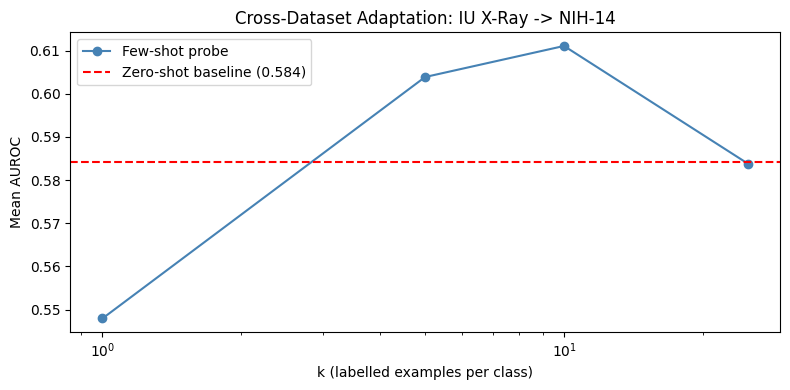

Plot saved to experiments/results/ext3_cross_dataset.png


In [22]:
# Visualise few-shot recovery curve
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("experiments/results", exist_ok=True)

zs_mean = zs_auroc["mean_auroc"]
fs_means = [results_by_k[k].get("mean_auroc", float("nan")) for k in K_SHOTS]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_SHOTS, fs_means, marker="o", color="steelblue", label="Few-shot probe")
ax.axhline(zs_mean, color="red", linestyle="--", label=f"Zero-shot baseline ({zs_mean:.3f})")
ax.set_xlabel("k (labelled examples per class)")
ax.set_ylabel("Mean AUROC")
ax.set_title("Cross-Dataset Adaptation: IU X-Ray -> NIH-14")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.savefig("experiments/results/ext3_cross_dataset.png", dpi=150)
plt.show()
print("Plot saved to experiments/results/ext3_cross_dataset.png")